   Julian_Date      Flux
0     0.000000  1.014867
1     0.020813  1.017331
2     0.041626  1.021835
3     0.062500  1.023046
4     0.083313  1.028071


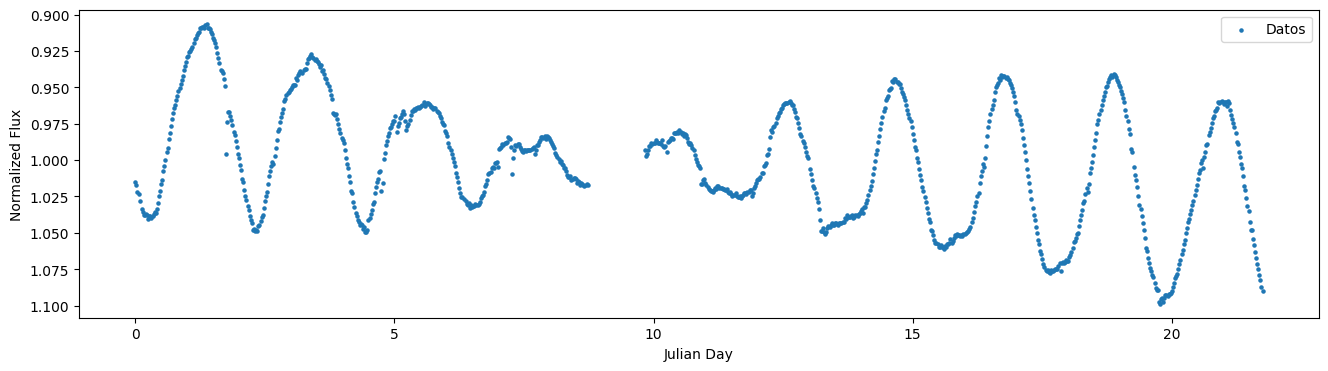

In [2]:
import astropy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#------------------Transformada de Fourier------
from numba import njit
@njit("f8[:](f8[:],f8[:],f8,f8,f8)",fastmath=True)
def NUDFT_grid(t_arg,m_arg,f_ini,f_end,df):
    """Non-Uniform Discrete Fourier Transform on an evenly-spaced frequency grid with the Kurtz (1985, MNRAS 213,773) algorithm"""
    dF = np.exp(-2j*np.pi*t_arg*df)
    F = np.zeros_like(np.arange(f_ini,f_end,df))
    curl = m_arg * np.exp(-2j*np.pi*t_arg*f_ini)
    F[0] = np.abs(np.sum(curl))**2
    for i in range(1,len(F)):
        curl = curl*dF
        F[i] = np.abs(np.sum(curl))**2
    return F


df = pd.read_csv(
    "/home/anthoni/Documents/MAESTRIA EN FÍSICA/TERCER SEMESTRE/Machine learning astrofísica/Lab8/SEMANA.12/T.TAURI.TESS/TIC_264739351.dat", 
    sep=r'\s+', 
    header=None, 
    names=["Julian_Date", "Flux"],
    usecols=[0, 1]
)

print(df.head())


plt.figure(figsize=(16,4))
plt.scatter(df["Julian_Date"], df["Flux"], s=5, label="Datos")
plt.xlabel('Julian Day')
plt.ylabel('Normalized Flux')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

f_max= 0.4505810311362987
p_max= 2.219356632653061


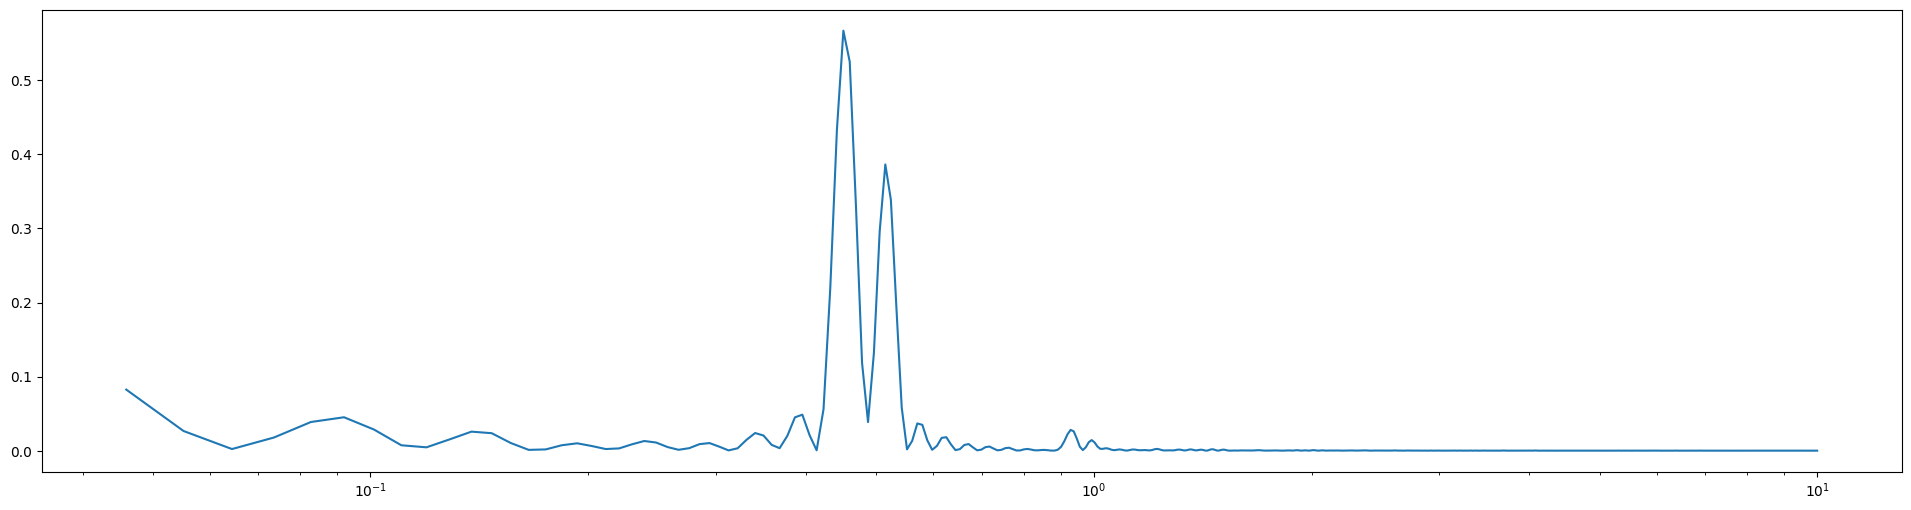

In [3]:
from astropy.timeseries import LombScargle
import numpy as np

T = df["Julian_Date"].values
M = df["Flux"].values


baseline = T.max() - T.min()
min_frequency = 1 / baseline        
max_frequency = float(10)                  
delta_f = 1.0 / (baseline)
frequency, power = LombScargle(T, M).autopower(
    minimum_frequency=min_frequency,
    maximum_frequency=max_frequency
)

fmax = frequency[np.argmax(power)]
print('f_max=',fmax)
print('p_max=',1/fmax)
plt.figure(figsize=(24,6))
plt.plot(frequency, power)
plt.xscale('log')


In [4]:
T = df["Julian_Date"].to_numpy(dtype=np.float64).copy()
M = df["Flux"].to_numpy(dtype=np.float64).copy()

delta_f = 1.0 / (5 * baseline)

F = NUDFT_grid(T, M, min_frequency, max_frequency, delta_f)


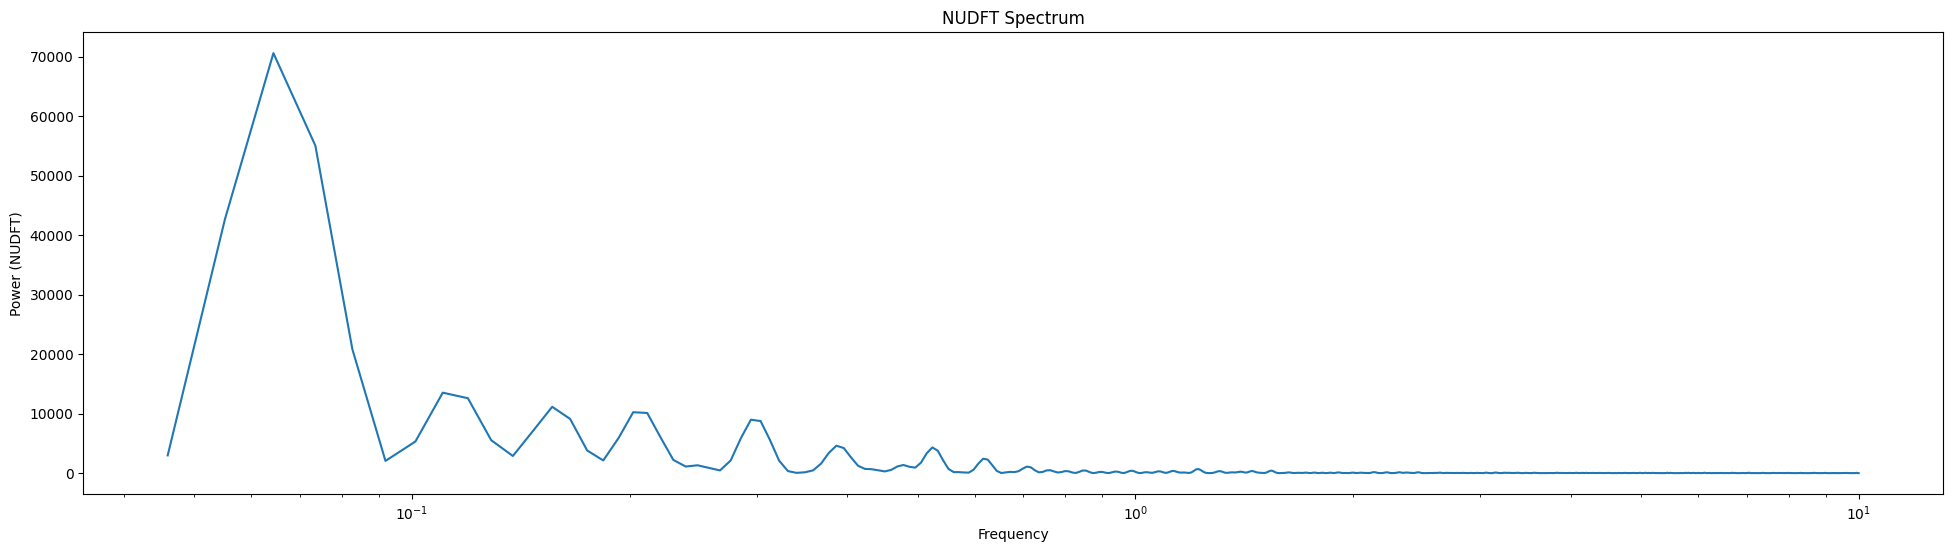

In [5]:
#print(F)
#print(T)

freq_grid = np.arange(min_frequency, max_frequency, delta_f)

plt.figure(figsize=(24,6))
plt.plot(freq_grid, F)
plt.xscale('log')
plt.xlabel("Frequency")
plt.ylabel("Power (NUDFT)")
plt.title("NUDFT Spectrum")
plt.show()


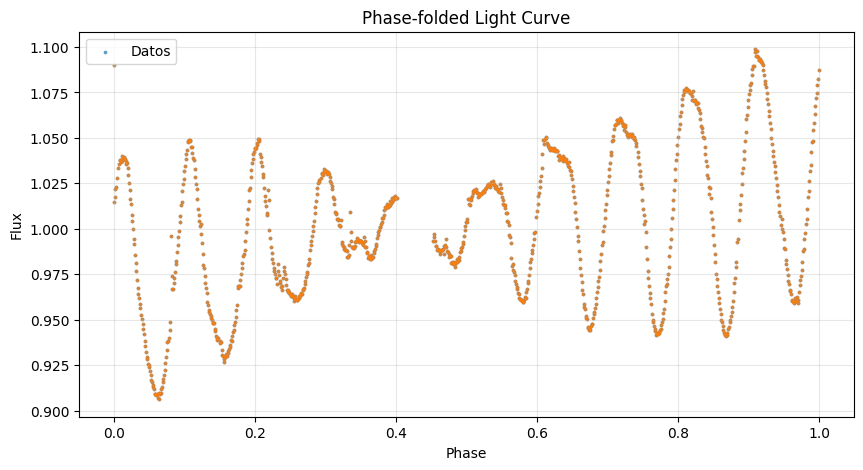

In [ ]:
phi = ((T - T[0])/baseline) % 1

idx = np.argsort(phi)
phi_sorted = phi[idx]
M_sorted = M[idx]

plt.figure(figsize=(10,5))

plt.scatter(phi_sorted, M_sorted, s=3, alpha=0.6, label="Datos")


plt.scatter(phi_sorted , M_sorted, s=3, alpha=0.6)

plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Phase-folded Light Curve")


plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [7]:
from toolz import itertoolz as tz
class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response

/tmp/ipykernel_26567/1198374372.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


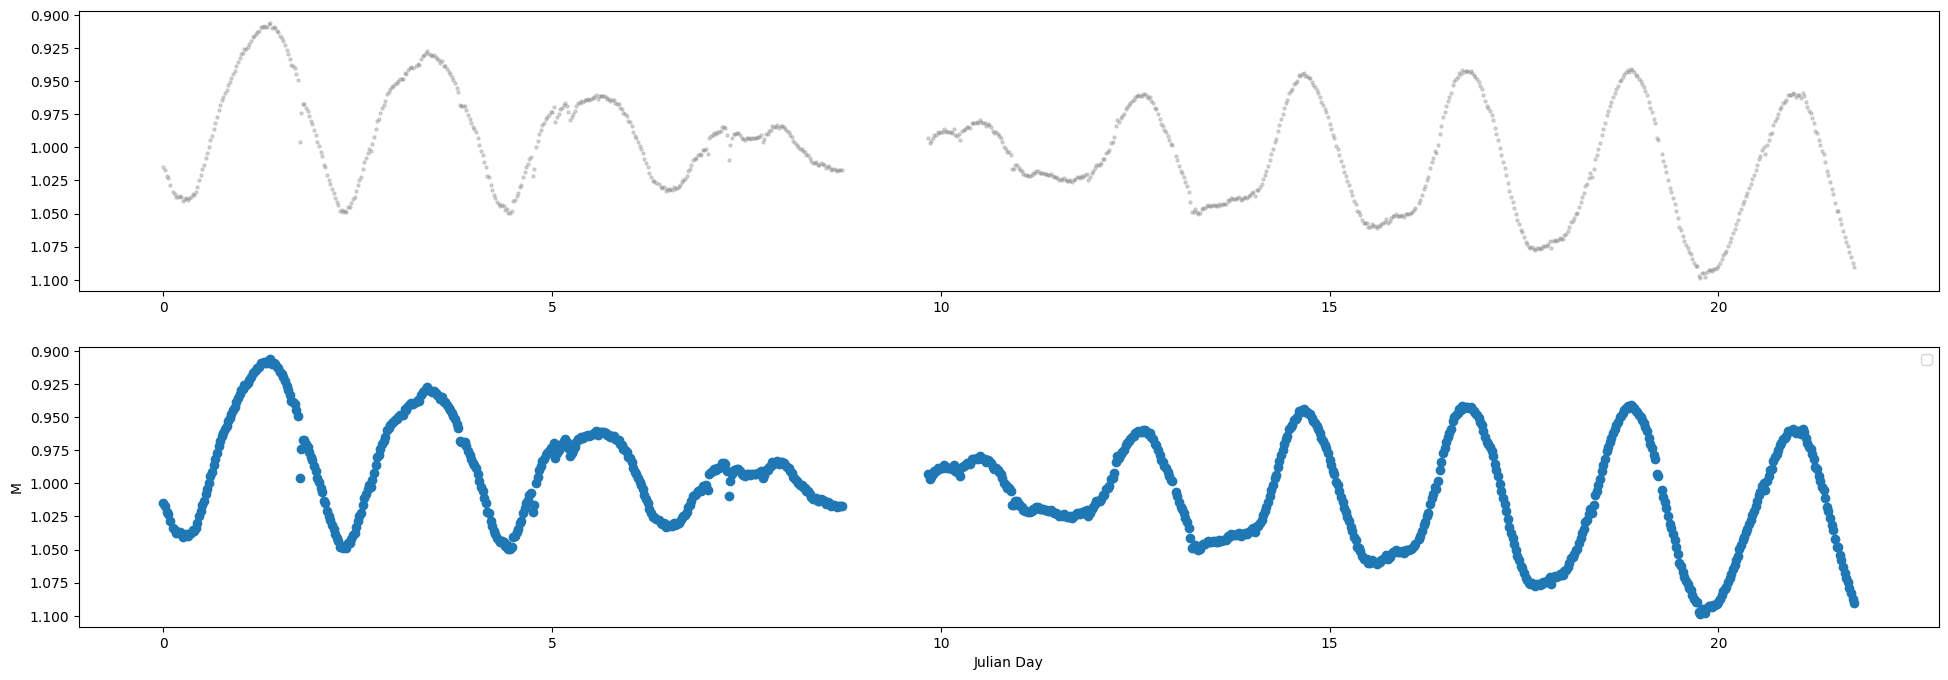

In [ ]:


T_max = np.argmax(T)

f_min = 1 / baseline

fourier = FourierSeries(n_terms=10,base_freq=f_min)

t_smooth = np.linspace(T.min(),T.max(),2000)
y_fit = fourier(t_smooth)

fig, axes=plt.subplots(2,1,figsize=(24,8))
axes[0].scatter(T, M, s=5, color='gray', alpha=0.3, label='Datos OGLE')
axes[0].invert_yaxis() 

axes[1].scatter(df["Julian_Date"], df["Flux"])
axes[1].set_xlabel('Julian Day')
axes[1].set_ylabel('M')
axes[1].invert_yaxis()
axes[1].legend()

plt.show()

Pre-whitening iterativo:
  f_1 = 0.45058 c/d   (P = 2.219 d)   σ_residuales = 0.0269
  f_2 = 0.51495 c/d   (P = 1.942 d)   σ_residuales = 0.0198
  f_3 = 0.04598 c/d   (P = 21.750 d)   σ_residuales = 0.0161
  f_4 = 0.07356 c/d   (P = 13.594 d)   σ_residuales = 0.0110
  f_5 = 0.92875 c/d   (P = 1.077 d)   σ_residuales = 0.0092


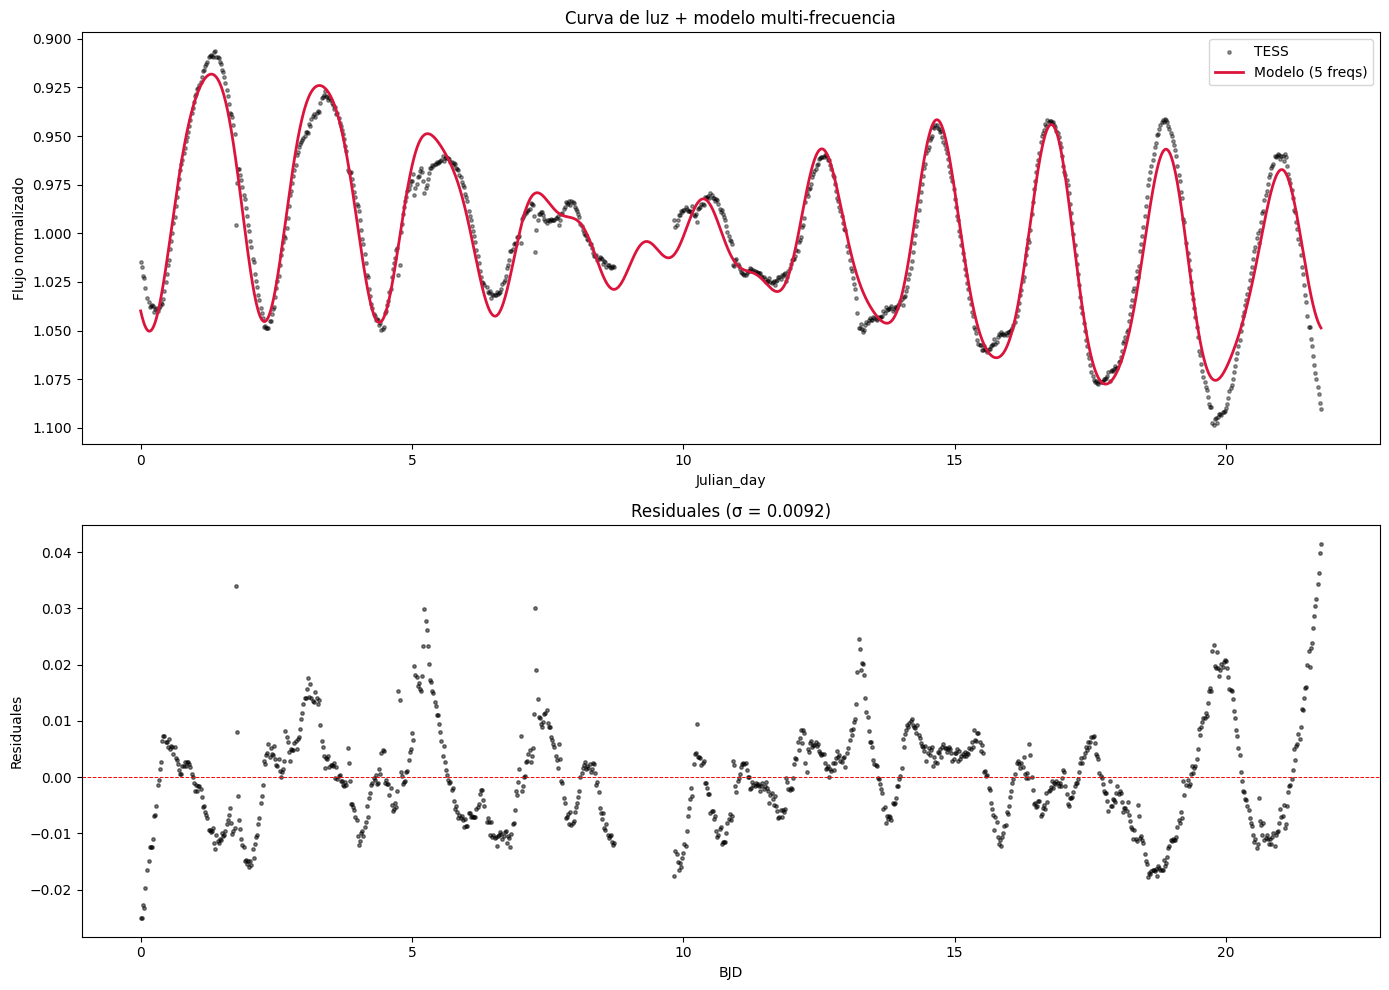


=== Frecuencias encontradas ===
f_1 = 0.450581 c/d  →  P_1 = 2.2194 d
f_2 = 0.514950 c/d  →  P_2 = 1.9419 d
f_3 = 0.045978 c/d  →  P_3 = 21.7497 d
f_4 = 0.073564 c/d  →  P_4 = 13.5936 d
f_5 = 0.928749 c/d  →  P_5 = 1.0767 d


In [ ]:
def find_frequency(t, m, f_min, f_max):

    freq, power = LombScargle(t, m).autopower(
        minimum_frequency=f_min, maximum_frequency=f_max
    )
    return freq[np.argmax(power)], freq, power


def prewhiten(T, M, n_freqs=5, f_min=None, f_max=10.0, verbose=True):

    if f_min is None:
        f_min = 1 / (T.max() - T.min())
    
    residuals = M.copy()
    found_freqs = []
    
    for i in range(n_freqs):

        f_i, _, _ = find_frequency(T, residuals, f_min, f_max)
        found_freqs.append(f_i)
        

        model = FourierSeries(custom_freqs=found_freqs)
        residuals_i = model.fit(T, M)
        residuals = residuals_i  
        
        if verbose:
            print(f"  f_{i+1} = {f_i:.5f} c/d   "
                  f"(P = {1/f_i:.3f} d)   "
                  f"σ_residuales = {residuals.std():.4f}")
    
    return found_freqs, model



print("Pre-whitening iterativo:")
freqs, fourier = prewhiten(T, M, n_freqs=5, f_max=10.0)


t_smooth = np.linspace(T.min(), T.max(), 5000)
y_fit = fourier(t_smooth)

#plots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].scatter(T, M, s=6, color='black', alpha=0.4, label='TESS')
axes[0].plot(t_smooth, y_fit, color='crimson', lw=2, 
             label=f'Modelo ({len(freqs)} freqs)')
axes[0].invert_yaxis()
axes[0].set_xlabel('Julian_day')
axes[0].set_ylabel('Flujo normalizado')
axes[0].legend()
axes[0].set_title('Curva de luz + modelo multi-frecuencia')


residuals = M - fourier(T)
axes[1].scatter(T, residuals, s=6, color='black', alpha=0.5)
axes[1].axhline(0, color='red', ls='--', lw=0.7)
axes[1].set_xlabel('BJD')
axes[1].set_ylabel('Residuales')
axes[1].set_title(f'Residuales (σ = {residuals.std():.4f})')

plt.tight_layout()
plt.savefig('ttauri.png')
plt.show()



